####  Homework 4: Building a Mini GPT from Scratch

#### **SID4:** 1598 | **SEED:** 1598 | **SLICE:** 598  
#### **HP_ID:** 2 | **CLS_A:** 8 | **CLS_B:** 5

#### I build a small GPT model using the provided Shakespeare text.
#### After training, I compare greedy decoding, temperature sampling, and top-k sampling.

#### Only SEED is used in this assignment. The other personal parameters are included as required.

In [18]:
%pip install -q torch numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


####  Setup

#### I use PyTorch to build and train the model. I set the random seeds to make the results repeatable in the same environment.

#### The required libraries are PyTorch, NumPy, and Matplotlib. If they are missing on another computer, install them once using`%pip install torch numpy matplotlib` before running the notebook.

In [19]:
import os
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

import math
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# Personal parameters
SID4 = 1598
SEED = SID4
SLICE = SID4 % 1000
HP_ID = SID4 % 6
CLS_A = SID4 % 10
CLS_B = (CLS_A + 1 + ((SID4 // 10) % 9)) % 10

# Set seeds for repeatable results.
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

torch.use_deterministic_algorithms(True)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

# Use CUDA if available; otherwise use the CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("Device:", device)
print("Seed:", SEED)

PyTorch version: 2.14.0
Device: cpu
Seed: 1598


## 1. Data Preparation

### Character-level tokenization

#### Each unique character gets an integer ID. Spaces, punctuation, and line breaks are kept. The mappings let me convert text to numbers and convert those numbers back to text.

In [20]:
from pathlib import Path

# Locate the instructor-provided dataset.
DATA_PATH = Path("shakespeare.txt")

if not DATA_PATH.is_file():
    raise FileNotFoundError(
        "Place the provided shakespeare.txt in the same folder "
        "as this notebook, then run this cell again."
    )

# Read the text.
with DATA_PATH.open("r", encoding="utf-8") as file:
    text = file.read()

# Create the character mappings.
chars = sorted(set(text))
vocab_size = len(chars)

char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for ch, i in char_to_idx.items()}

def encode(text):
    return [char_to_idx[ch] for ch in text]

def decode(ids):
    return "".join(idx_to_char[int(i)] for i in ids)

# Convert the text into a tensor of character IDs.
data = torch.tensor(encode(text), dtype=torch.long)

# Check that converting to IDs and back preserves the text.
assert decode(data) == text

print("Dataset filename:", DATA_PATH.name)
print("Total characters:", len(text))
print("Vocabulary size:", vocab_size)
print("\nText preview:\n")
print(text[:300])

Dataset filename: shakespeare.txt
Total characters: 1738
Vocabulary size: 49

Text preview:

ROMEO:
But, soft! what light through yonder window breaks?
It is the east, and Juliet is the sun.
Arise, fair sun, and kill the envious moon,
Who is already sick and pale with grief,
That thou her maid art far more fair than she.
Be not her maid, since she is envious;
Her vestal livery is but sick a


### Sliding-window dataset

#### Each input contains 128 characters. Its target is shifted forward by one character, so the model learns to predict the next character.

#### For example, an input of `ABCD` would have the target `BCDE`.The window moves one character at a time across the text.

In [21]:
SEQ_LEN = 128
BATCH_SIZE = 32

class CharDataset(Dataset):
    def __init__(self, data, seq_len):
        self.data = data
        self.seq_len = seq_len

        if len(data) <= seq_len:
            raise ValueError("The text is shorter than the required window.")

    def __len__(self):
        return len(self.data) - self.seq_len

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.seq_len]
        y = self.data[idx + 1 : idx + self.seq_len + 1]
        return x, y

dataset = CharDataset(data, SEQ_LEN)

# Shuffle the training examples using a fixed seed.
loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=torch.Generator().manual_seed(SEED),
    num_workers=0
)

print("Number of training pairs:", len(dataset))

# Show two input-target pairs as text.
for example, start in enumerate([0, 128], start=1):
    x, y = dataset[start]

    assert len(x) == len(y) == SEQ_LEN
    assert torch.equal(x[1:], y[:-1])

    print(f"\nExample {example}")
    print("Input:")
    print(decode(x))
    print("\nTarget:")
    print(decode(y))
    print("-" * 50)

Number of training pairs: 1610

Example 1
Input:
ROMEO:
But, soft! what light through yonder window breaks?
It is the east, and Juliet is the sun.
Arise, fair sun, and kill the 

Target:
OMEO:
But, soft! what light through yonder window breaks?
It is the east, and Juliet is the sun.
Arise, fair sun, and kill the e
--------------------------------------------------

Example 2
Input:
envious moon,
Who is already sick and pale with grief,
That thou her maid art far more fair than she.
Be not her maid, since she

Target:
nvious moon,
Who is already sick and pale with grief,
That thou her maid art far more fair than she.
Be not her maid, since she 
--------------------------------------------------


## 2. GPT Architecture

### Multi-head masked self-attention

I use four attention heads to learn different patterns in the text.
Each head works with part of the hidden features.

A causal mask prevents a character from looking at future characters.
The outputs from all heads are combined into one representation.

In [22]:


class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model, n_heads, seq_len):
        super().__init__()

        if d_model % n_heads != 0:
            raise ValueError("The hidden dimension must be divisible by the heads.")

        self.n_heads = n_heads
        self.head_dim = d_model // n_heads

        # Create queries, keys, and values together.
        self.qkv = nn.Linear(d_model, 3 * d_model)
        self.out_proj = nn.Linear(d_model, d_model)

        # True marks future positions that must be hidden.
        mask = torch.triu(
            torch.ones(seq_len, seq_len, dtype=torch.bool),
            diagonal=1
        )
        self.register_buffer("causal_mask", mask)

    def forward(self, x):
        B, T, C = x.shape

        q, k, v = self.qkv(x).chunk(3, dim=-1)

        # Split the hidden features into separate heads.
        q = q.reshape(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        k = k.reshape(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        v = v.reshape(B, T, self.n_heads, self.head_dim).transpose(1, 2)

        # Calculate attention scores within each head.
        scores = q @ k.transpose(-2, -1)
        scores = scores / math.sqrt(self.head_dim)

        # Hide future positions before applying softmax.
        scores = scores.masked_fill(
            self.causal_mask[:T, :T],
            float("-inf")
        )
        weights = F.softmax(scores, dim=-1)

        # Combine the values using the attention weights.
        out = weights @ v

        # Join the heads and apply the output projection.
        out = out.transpose(1, 2).contiguous().reshape(B, T, C)
        return self.out_proj(out)

In [23]:
# Test attention with two sequences of 128 positions.
attention = MultiHeadSelfAttention(D_MODEL, N_HEADS, SEQ_LEN)
test_input = torch.zeros(2, SEQ_LEN, D_MODEL)

with torch.no_grad():
    test_output = attention(test_input)

print("Input shape:", test_input.shape)
print("Output shape:", test_output.shape)

assert test_output.shape == test_input.shape
print("Attention shape check passed.")

Input shape: torch.Size([2, 128, 128])
Output shape: torch.Size([2, 128, 128])
Attention shape check passed.


### Transformer decoder block

Each block contains masked attention and a feedforward network.
Residual connections add the input back after each stage.

I follow the TA demo by applying LayerNorm before each stage.
The feedforward network uses Linear → GELU → Linear.

In [24]:
class DecoderBlock(nn.Module):
    def __init__(self, d_model, n_heads, seq_len):
        super().__init__()

        self.ln1 = nn.LayerNorm(d_model)
        self.attn = MultiHeadSelfAttention(d_model, n_heads, seq_len)
        self.ln2 = nn.LayerNorm(d_model)

        self.ff = nn.Sequential(
            nn.Linear(d_model, 4 * d_model),
            nn.GELU(),
            nn.Linear(4 * d_model, d_model)
        )

    def forward(self, x):
        # Attention followed by a residual connection.
        x = x + self.attn(self.ln1(x))

        # Feedforward network followed by a residual connection.
        x = x + self.ff(self.ln2(x))

        return x

### Complete GPT model

Token embeddings represent the characters, and learnable position
embeddings represent their order.

The model passes these through two decoder blocks, then predicts
a score for every possible next character.

In [25]:
N_LAYERS = 2

class TinyGPT(nn.Module):
    def __init__(self, vocab_size, d_model, n_heads, n_layers, seq_len):
        super().__init__()

        self.seq_len = seq_len

        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(seq_len, d_model)

        self.blocks = nn.Sequential(*[
            DecoderBlock(d_model, n_heads, seq_len)
            for _ in range(n_layers)
        ])

        self.ln = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size)

    def forward(self, idx):
        B, T = idx.shape

        if not 1 <= T <= self.seq_len:
            raise ValueError("Input length must be between 1 and seq_len.")

        positions = torch.arange(T, device=idx.device)

        # Add character information and position information.
        x = self.token_emb(idx) + self.pos_emb(positions)

        x = self.blocks(x)
        x = self.ln(x)

        return self.head(x)

# Reset the seed so the earlier test does not change initialization.
set_seed(SEED)

model = TinyGPT(
    vocab_size=vocab_size,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    n_layers=N_LAYERS,
    seq_len=SEQ_LEN
).to(device)

parameter_count = sum(p.numel() for p in model.parameters())

print(f"Total parameters: {parameter_count:,}")
print("Hidden dimension:", D_MODEL)
print("Number of heads:", N_HEADS)
print("Number of layers:", N_LAYERS)

Total parameters: 425,777
Hidden dimension: 128
Number of heads: 4
Number of layers: 2


### Checking the model

I change the second half of an input and check that predictions
in the first half stay the same. This checks that the model cannot
use future characters.

In [26]:
model.eval()

# Take one sequence from the dataset.
original = data[:SEQ_LEN].unsqueeze(0).to(device)
modified = original.clone()

# Change only the second half of the sequence.
modified[:, 64:] = (modified[:, 64:] + 1) % vocab_size

with torch.no_grad():
    original_output = model(original)
    modified_output = model(modified)

# One prediction per position, with a score for each character.
assert original_output.shape == (1, SEQ_LEN, vocab_size)

# Earlier predictions must not depend on later characters.
torch.testing.assert_close(
    original_output[:, :64],
    modified_output[:, :64],
    rtol=0,
    atol=1e-6
)

# Confirm that changing the input affects the later predictions.
assert not torch.allclose(
    original_output[:, 64:],
    modified_output[:, 64:]
)

print("Output shape:", original_output.shape)
print("Output shape and causal masking checks passed.")

Output shape: torch.Size([1, 128, 49])
Output shape and causal masking checks passed.


## 3. Training

#### I use Adam with a learning rate of 0.0003 and a batch size of 32.
#### The model trains for eight epochs.

#### Cross-entropy measures how well the model predicts the next character. I record the average training loss after each epoch.

In [27]:
from datetime import datetime
from pathlib import Path
import platform
import traceback

LEARNING_RATE = 3e-4
EPOCHS = 8

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

losses = []

# Save printed training results with timestamps.
log_path = Path("RUN_LOG.txt")
log_path.write_text("", encoding="utf-8")

def log(message):
    timestamp = datetime.now().astimezone().isoformat(timespec="seconds")
    line = f"[{timestamp}] {message}"
    print(line, flush=True)

    with log_path.open("a", encoding="utf-8") as file:
        file.write(line + "\n")

log(f"Python: {platform.python_version()} | PyTorch: {torch.__version__}")
log(f"Device: {device} | Seed: {SEED}")
log(f"Characters: {len(text)} | Vocabulary: {vocab_size}")
log(f"Training pairs: {len(dataset)} | Parameters: {parameter_count}")
log(f"Hidden dimension: {D_MODEL} | Heads: {N_HEADS} | Layers: {N_LAYERS}")
log(f"Optimizer: Adam | Learning rate: {LEARNING_RATE} | Batch size: {BATCH_SIZE}")

try:
    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0.0
        total_tokens = 0

        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            logits = model(x)

            loss = F.cross_entropy(
                logits.reshape(-1, vocab_size),
                y.reshape(-1)
            )

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()

            # Weight the average by the number of target characters.
            total_loss += loss.item() * y.numel()
            total_tokens += y.numel()

        average_loss = total_loss / total_tokens
        losses.append(average_loss)

        log(f"Epoch {epoch + 1}/{EPOCHS} | Loss: {average_loss:.4f}")

except Exception:
    log(traceback.format_exc())
    raise

[2026-09-17T11:29:04-07:00] Python: 3.13.9 | PyTorch: 2.14.0
[2026-09-17T11:29:04-07:00] Device: cpu | Seed: 1598
[2026-09-17T11:29:04-07:00] Characters: 1738 | Vocabulary: 49
[2026-09-17T11:29:04-07:00] Training pairs: 1610 | Parameters: 425777
[2026-09-17T11:29:04-07:00] Hidden dimension: 128 | Heads: 4 | Layers: 2
[2026-09-17T11:29:04-07:00] Optimizer: Adam | Learning rate: 0.0003 | Batch size: 32
[2026-09-17T11:29:08-07:00] Epoch 1/8 | Loss: 3.1064
[2026-09-17T11:29:12-07:00] Epoch 2/8 | Loss: 2.4798
[2026-09-17T11:29:16-07:00] Epoch 3/8 | Loss: 2.2785
[2026-09-17T11:29:19-07:00] Epoch 4/8 | Loss: 2.1753
[2026-09-17T11:29:23-07:00] Epoch 5/8 | Loss: 2.1050
[2026-09-17T11:29:27-07:00] Epoch 6/8 | Loss: 2.0409
[2026-09-17T11:29:31-07:00] Epoch 7/8 | Loss: 1.9715
[2026-09-17T11:29:34-07:00] Epoch 8/8 | Loss: 1.8965


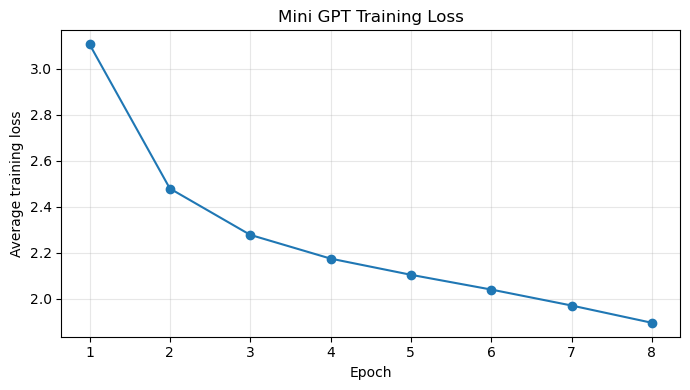

In [28]:
plt.figure(figsize=(7, 4))

plt.plot(
    range(1, EPOCHS + 1),
    losses,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Average training loss")
plt.title("Mini GPT Training Loss")
plt.xticks(range(1, EPOCHS + 1))
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("training_loss.png", dpi=150)
plt.show()

#### The training loss decreased from 3.1064 to 1.8965 over eight epochs. This shows that the model improved at predicting characters in the training text. I next check the quality of its generated text.

## 4. Sampling

#### I use the prompt `ROMEO:` and generate 300 new characters with each method. The model uses the most recent 128 characters as context.

#### Greedy decoding selects the highest-scoring character. Temperature sampling adjusts the probabilities, while top-k sampling limits the choices to the k highest-scoring characters.

In [29]:
@torch.no_grad()
def generate(prompt, method="greedy", max_new=300,
             temperature=1.0, top_k=None):
    model.eval()

    if not prompt:
        raise ValueError("The prompt cannot be empty.")

    ids = torch.tensor(
        encode(prompt),
        dtype=torch.long,
        device=device
    ).unsqueeze(0)

    for _ in range(max_new):
        # Keep only the available context window.
        context = ids[:, -model.seq_len:]
        logits = model(context)[:, -1, :]

        if method == "greedy":
            next_id = logits.argmax(dim=-1, keepdim=True)

        elif method == "temperature":
            if temperature <= 0:
                raise ValueError("Temperature must be positive.")

            probabilities = F.softmax(logits / temperature, dim=-1)
            next_id = torch.multinomial(probabilities, num_samples=1)

        elif method == "top_k":
            if top_k is None or not 1 <= top_k <= vocab_size:
                raise ValueError("k must be between 1 and the vocabulary size.")

            # Sample from exactly k candidates at temperature 1.0.
            values, indices = torch.topk(logits, k=top_k, dim=-1)
            probabilities = F.softmax(values, dim=-1)
            selected = torch.multinomial(probabilities, num_samples=1)
            next_id = indices.gather(-1, selected)

        else:
            raise ValueError("Unknown decoding method.")

        # Add the predicted character to the sequence.
        ids = torch.cat([ids, next_id], dim=1)

    return decode(ids[0].tolist())

### Greedy decoding

Greedy decoding always chooses the most likely next character.
It gives a repeatable output, but it can repeat words or phrases.

In [30]:
PROMPT = "ROMEO:"
MAX_NEW = 300
samples = {}

set_seed(SEED)

samples["Greedy"] = generate(
    prompt=PROMPT,
    method="greedy",
    max_new=MAX_NEW
)

log("Greedy decoding:\n" + samples["Greedy"])

[2026-09-17T11:30:41-07:00] Greedy decoding:
ROMEO:
I thy thame noull I thame, thame the the the thais:
He the nathe the the nathe ne ne namyspamamys ine ne athe nathe ne ispathe is
Souse is
The the ses
Thes s es s espallllll all al all es al al eeeees al al al al ak eeespes al eeeeespes





T:
T:
I buthees but but buspuspespes s spen es espespespe


### Temperature sampling

Temperature controls how spread out the character probabilities are.

- **0.5:** favors likely characters more strongly.
- **1.0:** uses the model’s original probabilities.
- **1.5:** allows more variety, including less likely characters.

I keep the prompt and output length the same and reset the seed
before each sample.

In [31]:
temperatures = [0.5, 1.0, 1.5]

for temperature in temperatures:
    set_seed(SEED)

    label = f"Temperature {temperature}"

    samples[label] = generate(
        prompt=PROMPT,
        method="temperature",
        max_new=MAX_NEW,
        temperature=temperature
    )

    log(f"\n{label}\n{'-' * 40}\n{samples[label]}\n")

[2026-09-17T11:30:45-07:00] 
Temperature 0.5
----------------------------------------
ROMEO:
What name thame
Why name name
I amend of whe
I se
Hames sellll al at t are bot at
JULIEOMEO:
He t see t weee I nout thake amy akshat sheell theshe bul beswiswill t t akswilll bes t akspe st IEThe e spee thee is:

Bespun buspusptheeel aspes eeail s
Hayspus ee, eal bus?

I t t eet therealll yeeeak t 

[2026-09-17T11:30:45-07:00] 
Temperature 1.0
----------------------------------------
ROMEO:
Weat be but namamy blt id iny e, nononof llech oulll my hy at;
OMy IEO, me bory;

J.
Whore but, t’s ais pe;

I nowortha m ho a wo cat fart te malo Rolo be the
What thaks name, age, my an sthakshall sere pece ind meenoul By my athis ce,
Be l he wheainot,
He!
, halth we t s thathiloulr alout he ghhou

[2026-09-17T11:30:46-07:00] 
Temperature 1.5
----------------------------------------
ROMEO:
Weat befucos ngall?
It Mw ik ULI grn nof latcwhoueve!
Why;LIt; d, amul my dyos, am,.
Whot! bul? t’s ai? peca;I n wurnzh

### Top-k sampling

#### Top-k sampling chooses from only the k most likely next characters.

#### I compare k = 2 and k = 20. A smaller k restricts the choices, while a larger k allows more variety. Both use temperature 1.0 to keep the comparison focused on k.

In [32]:
k_values = [2, 20]

for k in k_values:
    set_seed(SEED)

    label = f"Top-k {k}"

    samples[label] = generate(
        prompt=PROMPT,
        method="top_k",
        max_new=MAX_NEW,
        top_k=k
    )

    log(f"\n{label}\n{'-' * 40}\n{samples[label]}\n")

[2026-09-17T11:30:48-07:00] 
Top-k 2
----------------------------------------
ROMEO:
I thame
I nome that thou name nore no whe the the
RO:
I name nome thar thame nou tame
Rome
I name
O:
I’se
I t name
Rome
Whathame
IEThomel that t t thame noull t nelll w that the noul the
Soul t tous wousel that t that t noul wouee t the wo the welo thathee wee theel thespeswous

Hakswe t spe t the 

[2026-09-17T11:30:49-07:00] 
Top-k 20
----------------------------------------
ROMEO:
BMEO:
O:
H Roull beo!
T:
RNy Rwhy ard fomermy inakerewh but me s ha whad d ag:
Nome?
Showo!
JULI s ofat s an kld pana I nousw ameeef athathe, sw shy themey nat, hand, ay w w hershe!
Shoume f ny poo totheme ithilisul d oe?

Be, mal w ise ne osenourtoosal nge bor I wof, ne theno noworsicind,
Beat?
I 



## 5. Short Analysis

| Setting | What I observed |
|---|---|
| Greedy | Repeated fragments such as “the the the” and “al al al.” |
| Temperature 0.5 | Started with readable fragments such as “What name,” but later produced repeated letters and broken words. |
| Temperature 1.0 | Added variety, but many words and sentences were unclear. |
| Temperature 1.5 | Produced the most varied-looking text, with unusual spelling, capitalization, and punctuation. |
| Top-k 2 | Produced some recognizable fragments, such as “that thou name,” but frequently repeated “name” and “the.” |
| Top-k 20 | Produced more varied text than k = 2, but many words were malformed. |

**Most coherent:** I found top-k with k = 2 slightly more readable
because it produced recognizable short fragments. However, none of
the methods produced a fully coherent passage.

**Most diverse:** Temperature 1.5 appeared the most diverse, but
the extra variety also made the text harder to understand.

Greedy decoding always selects the most likely character.
Temperature sampling adjusts the probabilities before sampling.
Top-k sampling restricts the choices to the k most likely characters.

The training loss decreased from 3.1064 to 1.8965, but the generated
text still contained many errors. The dataset is very small, and
lower training loss does not guarantee meaningful text. These
observations describe one sample per setting.

## 6. Saving the Results

I save the trained model, its settings, and the character mappings.
I also save the training losses and generated samples for the
findings report.

In [33]:
import json

config = {
    "vocab_size": vocab_size,
    "d_model": D_MODEL,
    "n_heads": N_HEADS,
    "n_layers": N_LAYERS,
    "seq_len": SEQ_LEN
}

# Save the trained weights and information needed to rebuild the model.
checkpoint = {
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "config": config,
    "char_to_idx": char_to_idx,
    "idx_to_char": idx_to_char,
    "seed": SEED,
    "epochs": EPOCHS,
    "learning_rate": LEARNING_RATE,
    "batch_size": BATCH_SIZE,
    "losses": losses
}

torch.save(checkpoint, "mini_gpt_1598.pt")

# Save actual results for the report.
results = {
    "personal_parameters": {
        "SID4": SID4,
        "SEED": SEED,
        "SLICE": SLICE,
        "HP_ID": HP_ID,
        "CLS_A": CLS_A,
        "CLS_B": CLS_B
    },
    "environment": {
        "python": platform.python_version(),
        "pytorch": str(torch.__version__),
        "numpy": np.__version__,
        "platform": platform.platform(),
        "device": str(device)
    },
    "config": config,
    "total_characters": len(text),
    "training_pairs": len(dataset),
    "parameter_count": parameter_count,
    "optimizer": "Adam",
    "learning_rate": LEARNING_RATE,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "losses": losses,
    "prompt": PROMPT,
    "generated_characters": MAX_NEW,
    "samples": samples
}

Path("results.json").write_text(
    json.dumps(results, indent=2, ensure_ascii=False),
    encoding="utf-8"
)

log("Saved mini_gpt_1598.pt and results.json.")

[2026-09-17T11:30:54-07:00] Saved mini_gpt_1598.pt and results.json.


In [34]:
metrics = [
    "# Homework 4 Metrics",
    "",
    f"SID4: {SID4} | SEED: {SEED} | SLICE: {SLICE}",
    f"HP_ID: {HP_ID} | CLS_A: {CLS_A} | CLS_B: {CLS_B}",
    "",
    "| Setting | Value |",
    "|---|---|",
    f"| Total characters | {len(text)} |",
    f"| Vocabulary size | {vocab_size} |",
    f"| Training pairs | {len(dataset)} |",
    f"| Sequence length | {SEQ_LEN} |",
    f"| Parameters | {parameter_count:,} |",
    f"| Hidden dimension | {D_MODEL} |",
    f"| Attention heads | {N_HEADS} |",
    f"| Decoder blocks | {N_LAYERS} |",
    "| Optimizer | Adam |",
    f"| Learning rate | {LEARNING_RATE} |",
    f"| Batch size | {BATCH_SIZE} |",
    f"| Epochs | {EPOCHS} |",
    f"| Device | {device} |",
    "",
    "| Epoch | Average training loss |",
    "|---|---|"
]

for epoch, loss in enumerate(losses, start=1):
    metrics.append(f"| {epoch} | {loss:.6f} |")

metrics.extend([
    "",
    "Prompt: ROMEO:",
    f"Generated characters per sample: {MAX_NEW}",
    "Decoding: greedy; temperatures 0.5, 1.0, 1.5; top-k 2 and 20.",
    "Each sample uses SEED = 1598.",
    "",
    "The loss measures training performance; no held-out evaluation was used.",
    "Generated samples and software versions are saved in results.json."
])

Path("METRICS.md").write_text(
    "\n".join(metrics) + "\n",
    encoding="utf-8"
)

# This matches the notebook name shown in your screenshot.
notebook_name = "Homework4_1598.ipynb"

instructions = (
    "Original run: executed the notebook cells in order in Jupyter.\n"
    "To reproduce: keep shakespeare.txt beside the notebook and run "
    "all cells from a fresh kernel.\n\n"
    "Equivalent command-line execution after saving the notebook:\n"
    f'jupyter nbconvert --to notebook --execute "{notebook_name}" '
    '--output "Homework4_1598_executed.ipynb" '
    '--ExecutePreprocessor.timeout=1800\n'
)

Path("TRAINING_COMMAND.txt").write_text(instructions, encoding="utf-8")

log("Saved METRICS.md and TRAINING_COMMAND.txt.")
print("Files are saved in:", Path.cwd())

[2026-09-17T11:30:55-07:00] Saved METRICS.md and TRAINING_COMMAND.txt.
Files are saved in: /Users/harithagottumukkala/Desktop/DATA266_HW_1598/DATA266-1598_hw1/hw4
